# Model Definition, Training and Hyperparameter Tuning

In this section, a 1D Residual Network (ResNet) is designed and trained to perform multi-label classification on the PTB-XL ECG dataset.

## Architecture

The network follows the standard residual learning framework adapted for one-dimensional time-series data. Each residual block applies two 1D convolutions with batch normalisation and a skip connection that allows gradients to flow directly through the network. The architecture consists of four residual blocks with progressively increasing channel depth (64 → 128 → 256 → 512) and strided downsampling, followed by global average pooling and a linear output layer with one neuron per class.

## Training Setup

The model is trained using the Adam optimiser with a learning rate of 1e-3 and weight decay of 1e-4 for L2 regularisation. Binary cross-entropy with logits is used as the loss function, treating each class as an independent binary decision. A learning rate scheduler reduces the learning rate by a factor of 0.5 when validation loss plateaus for more than 5 consecutive epochs. The best checkpoint — selected by validation macro AUC — is saved and used for final evaluation.

## Evaluation

Predictions are made at segment level and then aggregated back to recording level using the element-wise maximum, following the approach established in the original PTB-XL benchmark. Performance is reported at both levels using macro AUC, macro F1, and a full per-class classification report.


## **Import modules and libraries**

In [1]:
import os
os.environ["TORCH_COMPILE_DISABLE"] = "1"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import numpy as np
import pandas as pd



## **Data Paths**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_BASE = "/content/drive/MyDrive/AI_in_Medicine_Project/"
PROCESSED_DATA = "/content/drive/MyDrive/AI_in_Medicine_Project/DL Part/processed_dataset/"
OUTPUT_DIR = "/content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/"

Mounted at /content/drive


## **Data Loading**

In [3]:
#Training segmented samples
X_train_seg = np.load(f"{PROCESSED_DATA}/train/segments/X_train_seg.npy")
Y_train_seg = np.load(f"{PROCESSED_DATA}/train/segments/Y_train_seg.npy")

#Validation segmented samples
X_val_seg = np.load(f"{PROCESSED_DATA}/val/segments/X_val_seg.npy")
Y_val_seg = np.load(f"{PROCESSED_DATA}/val/segments/Y_val_seg.npy")

#Testing segmented samples
X_test_seg = np.load(f"{PROCESSED_DATA}/test/segments/X_test_seg.npy")
Y_test_seg = np.load(f"{PROCESSED_DATA}/test/segments/Y_test_seg.npy")
ids_test = np.load(f"{PROCESSED_DATA}/test/segments/ids_test.npy")

#Testing full samples
Y_test = np.load(f"{PROCESSED_DATA}/test/Y_test.npy")

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP'] # superclasses defined by main documentation

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## **Defining Architecture**

In [4]:
import torch.nn as nn

# ── activation registry: name -> factory that returns a fresh module ──────────
ACTIVATIONS = {
    "relu": nn.ReLU,
    "gelu": nn.GELU,
    "mish": nn.Mish,
}

def make_activation(act):
    """Accept a name (str) or a callable factory; return a fresh module."""
    if isinstance(act, str):
        if act not in ACTIVATIONS:
            raise ValueError(f"unknown activation '{act}'. options: {list(ACTIVATIONS)}")
        return ACTIVATIONS[act]()
    return act()


class ResBlock1D(nn.Module):

    def __init__(self, in_ch, out_ch, kernel=7, stride=1, dropout=0.2, activation="relu"):
        super().__init__()
        pad = kernel // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.act1  = make_activation(activation)   # fresh instance
        self.act2  = make_activation(activation)   # fresh instance

        # shortcut: match dimensions if stride or channels change
        self.shortcut = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm1d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()

    def forward(self, x):
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = self.act2(out + self.shortcut(x))
        return out


class ECGResNet(nn.Module):
    """
    1D ResNet for multi-lead ECG classification.

    Input  : (batch, n_leads, signal_len)   e.g. (B, 12, 500)
    Output : (batch, n_classes)             raw logits

    Depth is set by `channels`: each entry is one residual block.
        [64, 128, 256, 512] -> 4 blocks (original)
        [64, 128]           -> 2 blocks
    The first block runs at stride 1 (the stem already downsamples);
    every subsequent block uses stride 2.
    """
    def __init__(self, n_leads=12, n_classes=5, dropout=0.2, activation="relu",
                 channels=(64, 128, 256, 512), stem_ch=64):
        super().__init__()
        channels = list(channels)
        if len(channels) < 1:
            raise ValueError("`channels` must contain at least one stage")

        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, stem_ch, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(stem_ch),
            make_activation(activation),
            nn.MaxPool1d(3, stride=2, padding=1)
        )

        blocks = []
        in_ch = stem_ch
        for i, out_ch in enumerate(channels):
            stride = 1 if i == 0 else 2          # first stage keeps resolution
            blocks.append(
                ResBlock1D(in_ch, out_ch, stride=stride,
                           dropout=dropout, activation=activation)
            )
            in_ch = out_ch
        self.blocks = nn.Sequential(*blocks)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(channels[-1], n_classes)   # head matches final width

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x)

## Define Data Loaders

In [5]:
def make_loader(X, Y, batch_size=64, shuffle=False):
    # X: (N, T, leads) → transpose to (N, leads, T) for Conv1d
    X_t = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
    Y_t = torch.tensor(Y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, Y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_seg, Y_train_seg, batch_size=64, shuffle=True)
val_loader   = make_loader(X_val_seg,   Y_val_seg)
test_loader  = make_loader(X_test_seg,  Y_test_seg)

## Training loop

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm

def run_experiment(
    name,
    model_fn,
    train_loader,
    val_loader,
    *,
    criterion=None,
    optimizer_fn=None,
    scheduler_fn=None,
    epochs=25,
    early_stop_patience=10,        # must exceed scheduler patience so LR drops first
    min_delta=1e-4,
    scheduler_metric="val_loss",   # what ReduceLROnPlateau.step() receives: "val_loss" or "val_auc"
    seed=42,                       # fixed init so depth/loss/act comparisons aren't confounded by RNG
    device=None,
    model_dir=None,
    save=True,
    verbose=True,
):
    """
    Train one ECGResNet configuration and return its history + best checkpoint.

    Only `name` and `model_fn` change between experiments; everything else
    defaults to the baseline setup. `model_fn` must be a zero-arg callable that
    returns a FRESH model, e.g.  lambda: ECGResNet(channels=[64, 128]).
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # defaults that reproduce the baseline -------------------------------------
    if criterion    is None: criterion    = nn.BCEWithLogitsLoss()
    if optimizer_fn is None: optimizer_fn = lambda p: torch.optim.Adam(p, lr=1e-3, weight_decay=1e-4)
    if scheduler_fn is None: scheduler_fn = lambda o: torch.optim.lr_scheduler.ReduceLROnPlateau(o, patience=5, factor=0.5)
    if model_dir    is None: model_dir    = f"{OUTPUT_DIR}models/resnet_new/"
    os.makedirs(model_dir, exist_ok=True)
    save_path = f"{model_dir}best_resnet_{name}.pt"

    # fair-comparison init -----------------------------------------------------
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    model     = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    scheduler = scheduler_fn(optimizer)

    history           = {"train_loss": [], "val_loss": [], "val_auc": []}
    best_auc          = 0.0
    best_epoch        = 0
    epochs_no_improve = 0

    epoch_bar = tqdm(range(1, epochs + 1), desc=f"[{name}]", unit="epoch")

    for epoch in epoch_bar:

        # ── train ─────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        train_bar  = tqdm(train_loader, desc=f"  ep {epoch}/{epochs} train",
                          leave=False, unit="batch")
        for X_batch, Y_batch in train_bar:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
            train_bar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss /= len(train_loader.dataset)

        # ── validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss, all_preds, all_labels = 0.0, [], []
        val_bar = tqdm(val_loader, desc=f"  ep {epoch}/{epochs} val  ",
                       leave=False, unit="batch")
        with torch.no_grad():
            for X_batch, Y_batch in val_bar:
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                logits     = model(X_batch)
                batch_loss = criterion(logits, Y_batch).item()
                val_loss  += batch_loss * len(X_batch)
                all_preds.append(torch.sigmoid(logits).cpu().numpy())
                all_labels.append(Y_batch.cpu().numpy())
                val_bar.set_postfix(loss=f"{batch_loss:.4f}")
        val_loss /= len(val_loader.dataset)

        preds_np  = np.concatenate(all_preds)
        labels_np = np.concatenate(all_labels)
        val_auc   = roc_auc_score(labels_np, preds_np, average="macro")

        scheduler.step(val_auc if scheduler_metric == "val_auc" else val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        # ── save best + early-stopping bookkeeping ────────────────────────────
        if val_auc > best_auc + min_delta:
            best_auc, best_epoch, epochs_no_improve = val_auc, epoch, 0
            if save:
                torch.save({
                    "name":        name,
                    "epoch":       epoch,
                    "model_state": model.state_dict(),
                    "optim_state": optimizer.state_dict(),
                    "val_auc":     val_auc,
                    "val_loss":    val_loss,
                    "classes":     list(SUPERCLASSES),
                }, save_path)
            tag = "✓ saved"
        else:
            epochs_no_improve += 1
            tag = f"no improve {epochs_no_improve}/{early_stop_patience}"

        epoch_bar.set_postfix({
            "tr": f"{train_loss:.4f}", "val": f"{val_loss:.4f}",
            "auc": f"{val_auc:.4f}", "best": f"{best_auc:.4f}", "status": tag,
        })

        if epochs_no_improve >= early_stop_patience:
            if verbose:
                print(f"[{name}] early stop @ epoch {epoch} "
                      f"(best val_auc {best_auc:.4f} @ epoch {best_epoch})")
            break

    if verbose:
        print(f"[{name}] best val AUC: {best_auc:.4f} @ epoch {best_epoch}  →  {save_path}")

    return {
        "name":       name,
        "history":    history,
        "best_auc":   best_auc,
        "best_epoch": best_epoch,
        "best_path":  save_path,
        "n_params":   sum(p.numel() for p in model.parameters()),
    }

## 1. Depth Experiments

In [ ]:
depth_configs = {
    "depth4": [64, 128, 256, 512],
    "depth2": [64, 128],
}
N_CLASSES = Y_train_seg.shape[1]
results_depth = {}
for tag, ch in depth_configs.items():
    results_depth[tag] = run_experiment(
        name=tag,
        model_fn=lambda ch=ch: ECGResNet(n_leads=12, n_classes=N_CLASSES, channels=ch),
        train_loader=train_loader,
        val_loader=val_loader,
    )

best_depth = max(results_depth.values(), key=lambda r: r["best_auc"])
print(f"\nDepth winner: {best_depth['name']} "
      f"(AUC {best_depth['best_auc']:.4f}, {best_depth['n_params']:,} params)")

[depth4]:   0%|          | 0/25 [00:00<?, ?epoch/s]

  ep 1/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 1/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

  ep 2/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 2/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

...

  ep 15/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 15/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

  ep 16/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 16/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

[depth2] early stop @ epoch 16 (best val_auc 0.9240 @ epoch 6)
[depth2] best val AUC: 0.9240 @ epoch 6  →  /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/models/resnet_new/best_resnet_depth2.pt

Depth winner: depth2 (AUC 0.9240, 250,885 params)


## Making plots

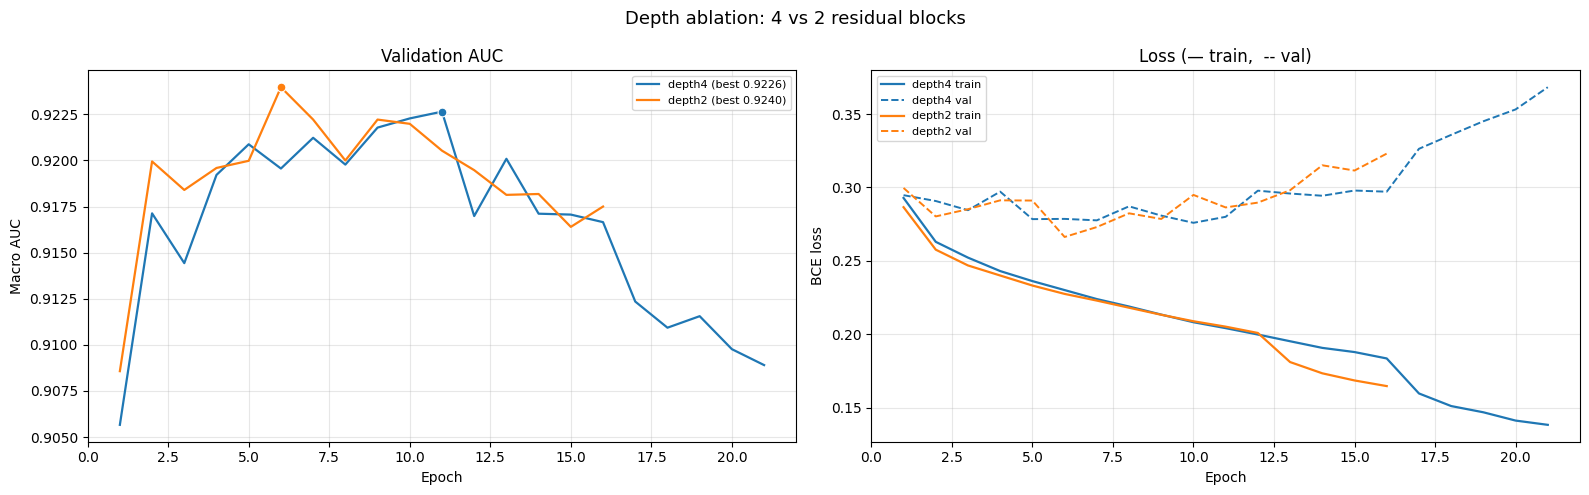

In [ ]:
import matplotlib.pyplot as plt

def plot_runs(results, title="", figsize=(16, 5)):
    """
    Overlay val-AUC and train/val-loss curves across runs.

    `results` : dict {tag -> result dict from run_experiment}
                (each result has result["history"] with
                 train_loss / val_loss / val_auc lists)
    """
    fig, (ax_auc, ax_loss) = plt.subplots(1, 2, figsize=figsize)
    if title:
        fig.suptitle(title, fontsize=13)

    cmap = plt.get_cmap("tab10")

    for i, (tag, res) in enumerate(results.items()):
        h      = res["history"]
        color  = cmap(i)
        epochs = range(1, len(h["val_auc"]) + 1)

        # ── AUC (left) ────────────────────────────────────────────────────────
        ax_auc.plot(epochs, h["val_auc"], color=color, lw=1.6,
                    label=f"{tag} (best {res['best_auc']:.4f})")
        # mark the selected epoch
        ax_auc.scatter([res["best_epoch"]], [res["best_auc"]],
                       color=color, s=40, zorder=5, edgecolor="white", linewidth=0.8)

        # ── Loss (right): train solid, val dashed ────────────────────────────
        ax_loss.plot(epochs, h["train_loss"], color=color, lw=1.6,
                     label=f"{tag} train")
        ax_loss.plot(epochs, h["val_loss"], color=color, lw=1.4, ls="--",
                     label=f"{tag} val")

    ax_auc.set_title("Validation AUC")
    ax_auc.set_xlabel("Epoch"); ax_auc.set_ylabel("Macro AUC")
    ax_auc.legend(fontsize=8); ax_auc.grid(alpha=0.3)

    ax_loss.set_title("Loss (— train,  -- val)")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("BCE loss")
    ax_loss.legend(fontsize=8); ax_loss.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_runs(results_depth, title="Depth ablation: 4 vs 2 residual blocks")

## Observations:

The two-block model edges out the four-block one on peak AUC (0.9240 vs 0.9226) while reaching its best far earlier (epoch 6 vs 11), so the extra depth buys no discriminative gain here and just costs training time. The gap is ~0.0014 AUC, which is well within single-seed noise.

Both models overfit: train loss falls monotonically (deeper one further, to ~0.14 vs ~0.16, reflecting its larger capacity) while val loss turns upward after roughly epoch 8–10 in both. The deeper model overfits harder in absolute terms — its val loss climbs to ~0.37 vs ~0.32 — consistent with more parameters memorizing the training set, and its AUC degrades more steeply post-peak (down to ~0.909).

Notably, val loss and val AUC diverge for both runs: AUC peaks and then declines while val loss is already rising. That's expected for a thresholded-vs-ranking metric split, and it's the reason selecting on AUC rather than loss matters here.

Bottom line for the ablation: depth doesn't help on this task — the shallower model matches or slightly beats the deeper one with less compute and milder overfitting, so depth2 is the sensible base to carry into the loss-function phase.

## WINNER IS MODEL WITH 2 RESIDUAL BLOCKS

## 2. Loss experiments

### Weight for weighted BCE

In [ ]:
# ── pos_weight: computed once from the TRAIN labels only ─────────────────────
# Y_train_seg: (N, n_classes) float tensor or numpy array
Y_tr = torch.tensor(Y_train_seg, dtype=torch.float32)
n_neg = (Y_tr == 0).sum(0)
n_pos = (Y_tr == 1).sum(0).clamp(min=1)
pos_weight = (n_neg / n_pos).to(DEVICE)          # shape: (n_classes,)

## Multilabel Focal Loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Sigmoid focal loss for multi-label classification (RetinaNet-style).

    Operates on raw logits, exactly like BCEWithLogitsLoss, so it drops into
    the same training loop. For each element with probability p = sigmoid(logit):

        p_t   = p   if target == 1 else (1 - p)
        focal = (1 - p_t) ** gamma          # down-weights easy examples
        alpha_t = alpha if target == 1 else (1 - alpha)
        loss  = alpha_t * focal * BCE(logit, target)

    Args:
        alpha : balances positive vs negative classes in [0, 1].
                0.25 (default) is the RetinaNet value; it weights the rarer
                POSITIVE class at 0.25 and negatives at 0.75 — counterintuitive,
                but it's applied *after* the focal term which already emphasises
                hard positives. Set to 0.5 for no class balancing, or pass a
                per-class tensor of shape (n_classes,) for finer control.
        gamma : focusing strength; 0 recovers plain BCE, 2.0 is standard.
        reduction : "mean" | "sum" | "none".
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.type_as(logits)

        # per-element BCE on logits (numerically stable, no manual sigmoid)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        # p_t = probability assigned to the TRUE class
        p     = torch.sigmoid(logits)
        p_t   = p * targets + (1 - p) * (1 - targets)
        focal = (1 - p_t) ** self.gamma

        loss = focal * bce

        # alpha balancing (scalar or per-class tensor)
        if self.alpha is not None:
            if isinstance(self.alpha, torch.Tensor):
                alpha = self.alpha.to(logits.device)          # shape (n_classes,)
            else:
                alpha = self.alpha
            alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

## Running test

In [ ]:
WINNER_CHANNELS = [64, 128]   # ← set from Phase 1 result

loss_configs = {
    "bce":          nn.BCEWithLogitsLoss(),
    "weighted_bce": nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE)),
    "focal":        FocalLoss(),
}

results_loss = {}
for tag, crit in loss_configs.items():
    results_loss[tag] = run_experiment(
        name=f"loss_{tag}",
        model_fn=lambda: ECGResNet(n_leads=12, n_classes=N_CLASSES, channels=WINNER_CHANNELS),
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=crit,
    )

[loss_bce]:   0%|          | 0/25 [00:00<?, ?epoch/s]

  ep 1/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 1/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

  ep 2/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 2/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

...

  ep 24/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 24/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

  ep 25/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 25/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

[loss_focal] best val AUC: 0.9244 @ epoch 23  →  /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/models/resnet_new/best_resnet_loss_focal.pt


## **Plots**

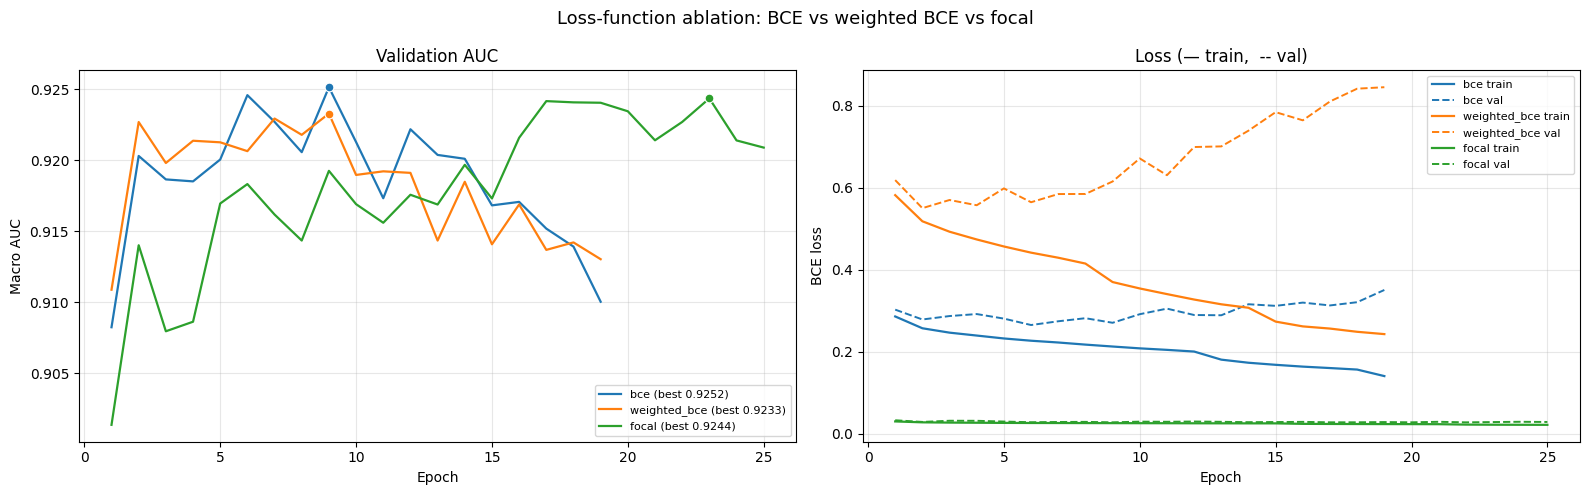

In [ ]:
plot_runs(results_loss, title="Loss-function ablation: BCE vs weighted BCE vs focal")

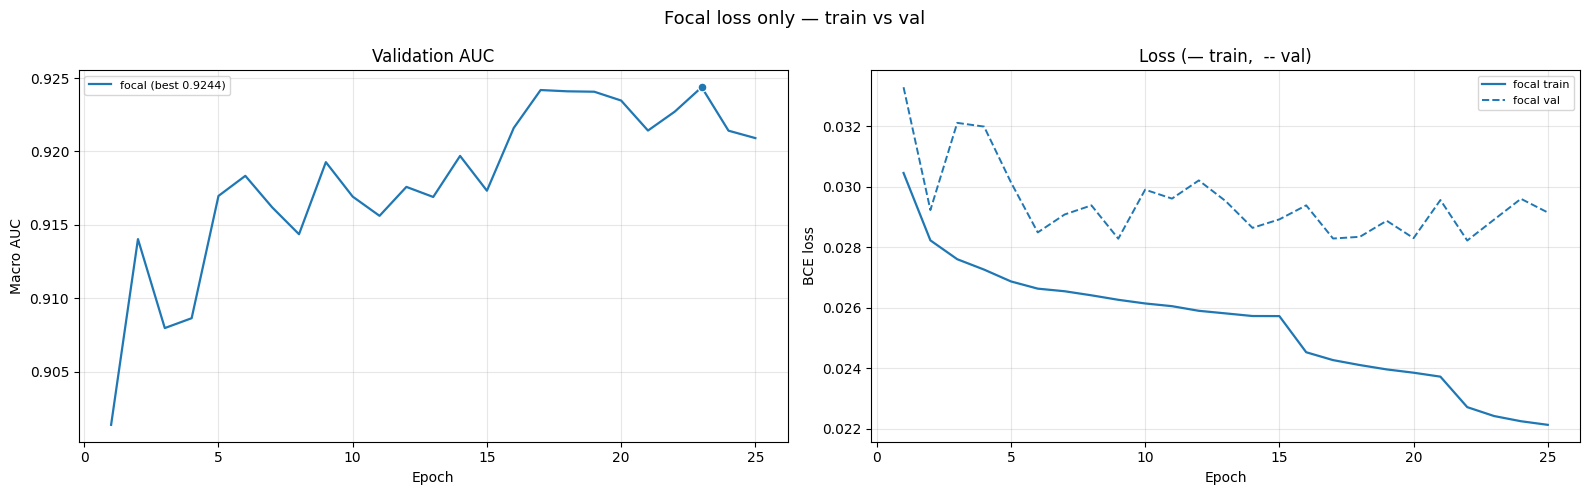

In [ ]:
plot_runs({"focal": results_loss["focal"]},
          title="Focal loss only — train vs val")

## Observations:

The highest AUC was obtained BCE, however these differences are particularly small.

Focal Loss shows more stable convergence (flat val loss, sustained AUC plateau) and gentler overfitting compared to BCE and WBCE.

Thus, the winner in this experiment is model with Focal Loss.

## 3. Activation functions

In [ ]:
WINNER_CHANNELS  = [64, 128]        # ← Phase 1
WINNER_CRITERION = FocalLoss()      # ← Phase 2 (focal, default alpha=0.25 / gamma=2.0)

results_act = {}
for act in ["relu", "gelu", "mish"]:
    results_act[act] = run_experiment(
        name=f"act_{act}",
        model_fn=lambda act=act: ECGResNet(n_leads=12, n_classes=N_CLASSES,
                                            channels=WINNER_CHANNELS, activation=act),
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=WINNER_CRITERION,
    )

best_act = max(results_act.values(), key=lambda r: r["best_auc"])
print(f"\nActivation winner: {best_act['name']} (AUC {best_act['best_auc']:.4f})")

[act_relu]:   0%|          | 0/25 [00:00<?, ?epoch/s]

  ep 1/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 1/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

  ep 2/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 2/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

...

  ep 24/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 24/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

  ep 25/25 train:   0%|          | 0/1361 [00:00<?, ?batch/s]

  ep 25/25 val  :   0%|          | 0/172 [00:00<?, ?batch/s]

[act_mish] best val AUC: 0.9188 @ epoch 24  →  /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/models/resnet_new/best_resnet_act_mish.pt

Activation winner: act_relu (AUC 0.9239)


## Plots

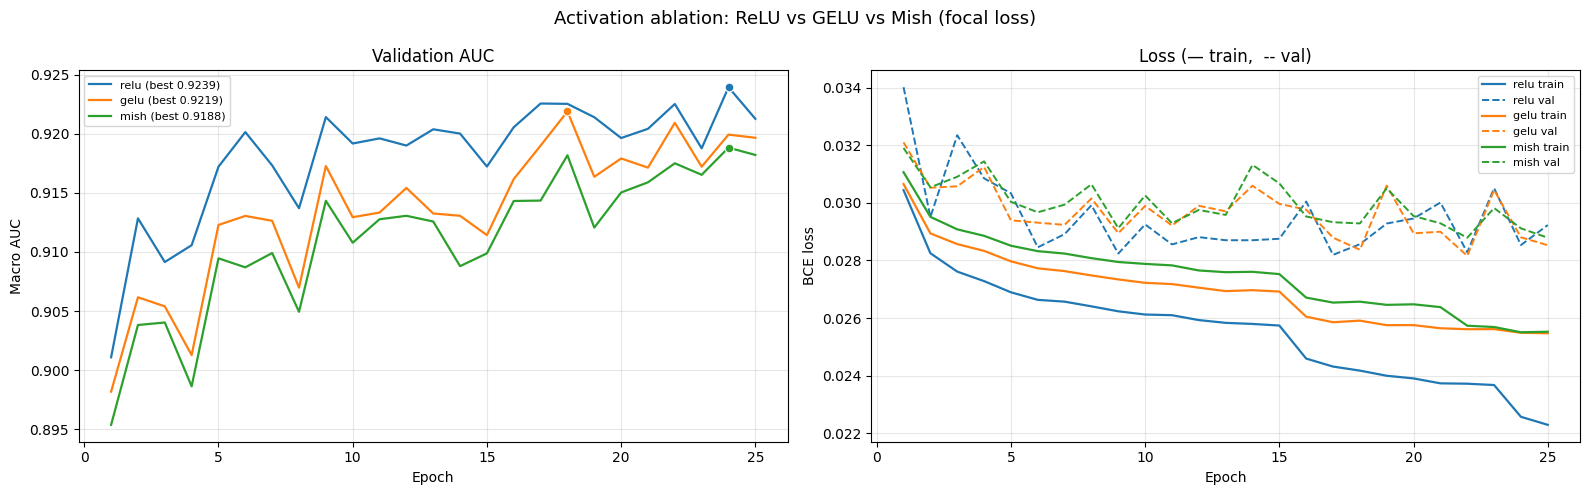

In [ ]:
plot_runs(results_act, title="Activation ablation: ReLU vs GELU vs Mish (focal loss)")

## Observations:

All of the activation functions behave simillarly. ReLU achieved the biggest AUC score. ReLU is not a winning choice only because of the AUC value but also because of the parsimony.

## Evalution on Test Data


  Evaluating: baseline

── Metrics (baseline) ──


,Accuracy,Sensitivity,Specificity,Precision,Youden,F-score,AUC,AUPR
Class,,,,,,,,
NORM,0.8545,0.9340,0.7936,0.7763,0.7276,0.8479,0.9356,0.9059
MI,0.8491,0.7578,0.8704,0.5777,0.6282,0.6556,0.9121,0.7401
STTC,0.8927,0.7850,0.9250,0.7581,0.7100,0.7713,0.9305,0.8000
CD,0.8659,0.7928,0.8873,0.6724,0.6800,0.7276,0.9116,0.8026
HYP,0.9164,0.5830,0.9540,0.5882,0.5369,0.5856,0.9046,0.6112
macro,0.8757,0.7705,0.8860,0.6745,0.6566,0.7176,0.9189,0.7720


saved → /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/figures/Confusion_—_baseline.svg


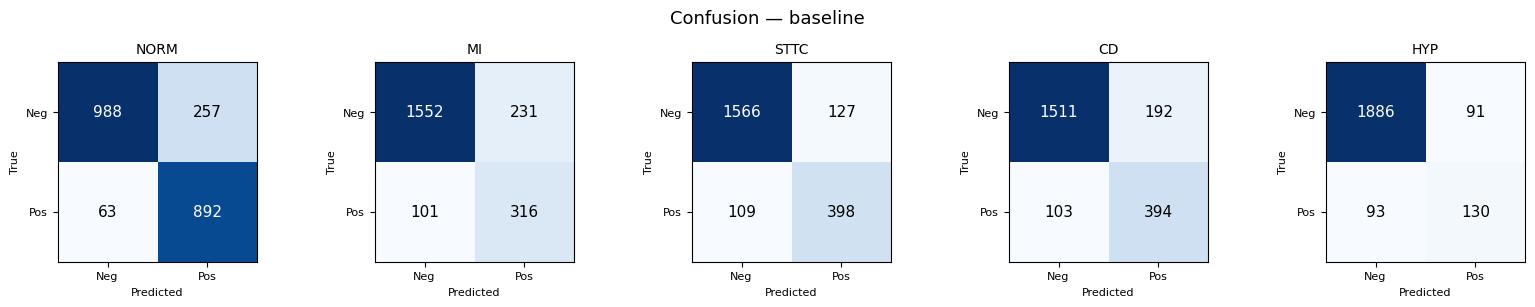

saved → /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/figures/ROC_—_baseline.svg


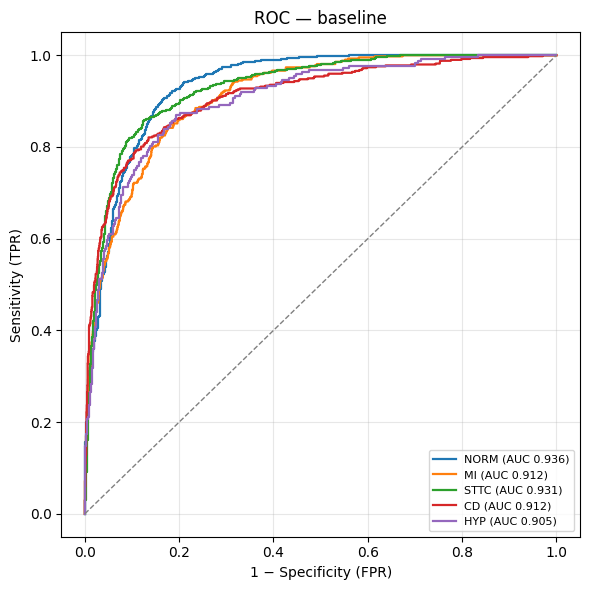

saved 2200 records → /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/gradcam/results_gradcam_baseline.csv
  TP: 1800   FP: 765   FN: 431

  Evaluating: final

── Metrics (final) ──


,Accuracy,Sensitivity,Specificity,Precision,Youden,F-score,AUC,AUPR
Class,,,,,,,,
NORM,0.8677,0.8691,0.8667,0.8333,0.7358,0.8508,0.9383,0.9064
MI,0.8923,0.6091,0.9585,0.7744,0.5676,0.6819,0.9237,0.7756
STTC,0.8786,0.5779,0.9687,0.8468,0.5466,0.6870,0.9330,0.8097
CD,0.8923,0.6338,0.9677,0.8514,0.6015,0.7266,0.9153,0.8271
HYP,0.9209,0.2960,0.9914,0.7952,0.2874,0.4314,0.9035,0.6204
macro,0.8904,0.5972,0.9506,0.8202,0.5478,0.6755,0.9228,0.7878


saved → /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/figures/Confusion_—_final.svg


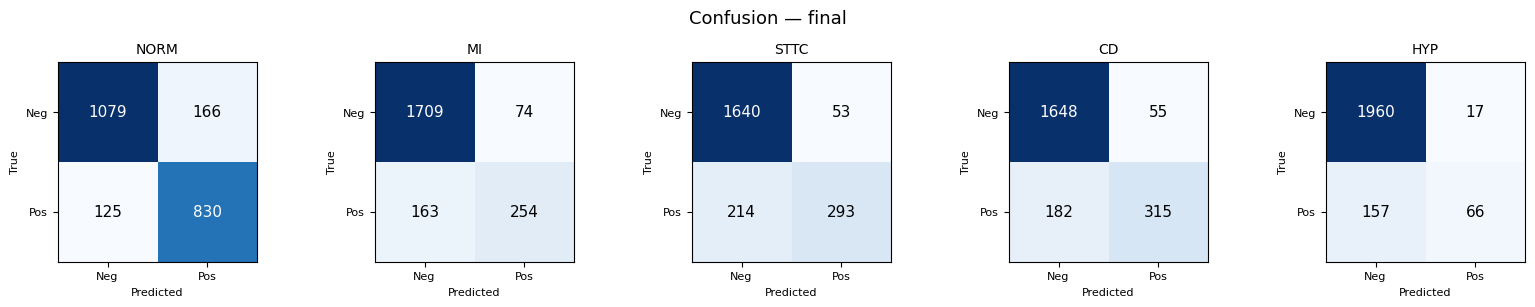

saved → /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/figures/ROC_—_final.svg


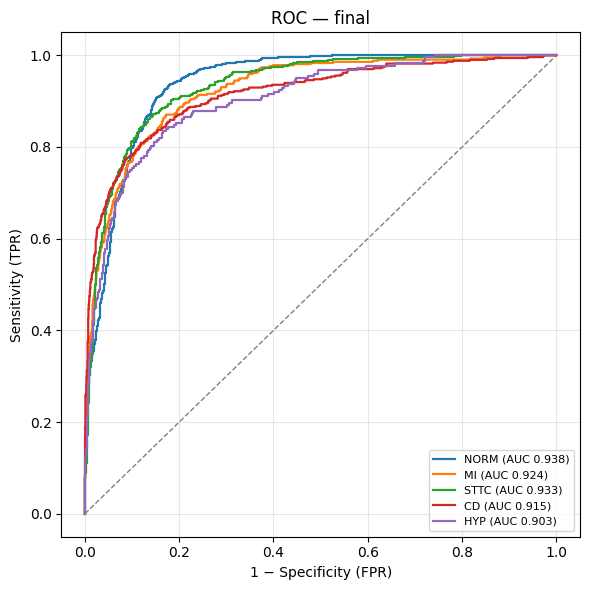

saved 2200 records → /content/drive/MyDrive/AI_in_Medicine_Project/DL Part/outputs/gradcam/results_gradcam_final.csv
  TP: 1589   FP: 347   FN: 721

✓ Evaluation complete for all models.


In [6]:
import os
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, multilabel_confusion_matrix

# ── config ────────────────────────────────────────────────────────────────────
CLASS_NAMES = list(SUPERCLASSES)
MODEL_DIR   = f"{OUTPUT_DIR}models/resnet_new/"
FIG_DIR     = f"{OUTPUT_DIR}figures/"
os.makedirs(FIG_DIR, exist_ok=True)
N_CLASSES = Y_train_seg.shape[1]



# ── 1. record-level inference ─────────────────────────────────────────────────
@torch.no_grad()
def collect_predictions_record_level(model, test_loader, ids_test, device):
    model.eval()
    all_probs, all_labels = [], []
    for X_batch, Y_batch in test_loader:
        probs = torch.sigmoid(model(X_batch.to(device))).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(Y_batch.numpy())

    seg_probs  = np.concatenate(all_probs)
    seg_labels = np.concatenate(all_labels)

    n_records  = ids_test.max() + 1
    rec_probs  = np.zeros((n_records, seg_probs.shape[1]))
    rec_labels = np.zeros((n_records, seg_labels.shape[1]))

    for seg_i, rec_i in enumerate(ids_test):
        rec_probs[rec_i]  = np.maximum(rec_probs[rec_i],  seg_probs[seg_i])
        rec_labels[rec_i] = np.maximum(rec_labels[rec_i], seg_labels[seg_i])

    return rec_probs, rec_labels


# ── 2. metrics ────────────────────────────────────────────────────────────────
def compute_metrics(probs, labels, class_names, threshold=0.5):
    n_classes = labels.shape[1]
    thr   = np.full(n_classes, threshold) if np.isscalar(threshold) else np.asarray(threshold)
    preds = (probs >= thr).astype(int)

    rows = []
    for c in range(n_classes):
        y, p, pr = labels[:, c], preds[:, c], probs[:, c]
        tp = int(((p == 1) & (y == 1)).sum())
        fp = int(((p == 1) & (y == 0)).sum())
        tn = int(((p == 0) & (y == 0)).sum())
        fn = int(((p == 0) & (y == 1)).sum())

        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        acc  = (tp + tn) / (tp + tn + fp + fn)
        fsc  = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0

        rows.append({
            "Class":       class_names[c],
            "Accuracy":    acc,
            "Sensitivity": sens,
            "Specificity": spec,
            "Precision":   prec,
            "Youden":      sens + spec - 1,
            "F-score":     fsc,
            "AUC":         roc_auc_score(y, pr),
            "AUPR":        average_precision_score(y, pr),
        })

    df = pd.DataFrame(rows).set_index("Class")
    df.loc["macro"] = df.mean(numeric_only=True)
    return df.round(4)


# ── 3. confusion matrix grid ──────────────────────────────────────────────────
def plot_confusion_grid(probs, labels, class_names, threshold=0.5,
                        title="", export=False, out_path=None, fmt="svg"):
    thr   = np.full(len(class_names), threshold) if np.isscalar(threshold) else np.asarray(threshold)
    preds = (probs >= thr).astype(int)
    cms   = multilabel_confusion_matrix(labels, preds)

    n   = len(class_names)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3))
    if n == 1: axes = [axes]
    if title: fig.suptitle(title, fontsize=13)

    for ax, cm, name in zip(axes, cms, class_names):
        ax.imshow(cm, cmap="Blues")
        for (i, j), v in np.ndenumerate(cm):
            ax.text(j, i, f"{v}", ha="center", va="center",
                    color="white" if v > cm.max() / 2 else "black", fontsize=11)
        ax.set_title(name, fontsize=10)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Neg", "Pos"], fontsize=8)
        ax.set_yticks([0, 1]); ax.set_yticklabels(["Neg", "Pos"], fontsize=8)
        ax.set_xlabel("Predicted", fontsize=8)
        ax.set_ylabel("True", fontsize=8)

    plt.tight_layout()
    if export:
        out_path = out_path or f"{FIG_DIR}{(title or 'confusion').replace(' ','_').replace(':','')}.{fmt}"
        fig.savefig(out_path, format=fmt, bbox_inches="tight")
        print(f"saved → {out_path}")
    plt.show()


# ── 4. ROC curves ─────────────────────────────────────────────────────────────
def plot_roc_curves(probs, labels, class_names,
                    title="", export=False, out_path=None, fmt="svg"):
    fig, ax = plt.subplots(figsize=(6, 6))
    cmap = plt.get_cmap("tab10")
    for c, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(labels[:, c], probs[:, c])
        auc = roc_auc_score(labels[:, c], probs[:, c])
        ax.plot(fpr, tpr, color=cmap(c), lw=1.6, label=f"{name} (AUC {auc:.3f})")
    ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1)
    ax.set_xlabel("1 − Specificity (FPR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_title(title or "ROC curves")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if export:
        out_path = out_path or f"{FIG_DIR}{(title or 'roc').replace(' ','_').replace(':','')}.{fmt}"
        fig.savefig(out_path, format=fmt, bbox_inches="tight")
        print(f"saved → {out_path}")
    plt.show()


# ── 5. GradCAM CSV export ─────────────────────────────────────────────────────
def export_gradcam_csv(probs, labels, class_names, out_path, threshold=0.5):
    preds_bin = (probs >= threshold).astype(int)
    n_classes = labels.shape[1]
    rows = []
    for rec_i in range(labels.shape[0]):
        row = {"record_id": rec_i}
        for ci, cls in enumerate(class_names):
            row[f"prob_{cls}"]      = round(float(probs[rec_i, ci]), 4)
            row[f"gt_{cls}"]        = int(labels[rec_i, ci])
            row[f"predicted_{cls}"] = int(preds_bin[rec_i, ci])
        gt_set   = [class_names[ci] for ci in range(n_classes) if labels[rec_i, ci]    == 1]
        pred_set = [class_names[ci] for ci in range(n_classes) if preds_bin[rec_i, ci] == 1]
        row["ground_truth_labels"] = str(gt_set)   if gt_set   else "['none']"
        row["predicted_labels"]    = str(pred_set) if pred_set else "['none']"
        row["is_tp"] = int(any(labels[rec_i, ci] == 1 and preds_bin[rec_i, ci] == 1 for ci in range(n_classes)))
        row["is_fp"] = int(any(labels[rec_i, ci] == 0 and preds_bin[rec_i, ci] == 1 for ci in range(n_classes)))
        row["is_fn"] = int(any(labels[rec_i, ci] == 1 and preds_bin[rec_i, ci] == 0 for ci in range(n_classes)))
        rows.append(row)
    df = pd.DataFrame(rows)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    df.to_csv(out_path, index=False)
    print(f"saved {len(df)} records → {out_path}")
    print(f"  TP: {df['is_tp'].sum()}   FP: {df['is_fp'].sum()}   FN: {df['is_fn'].sum()}")
    return df


# ── 6. models to evaluate ─────────────────────────────────────────────────────
models_to_test = {
    "baseline": dict(
        ckpt="best_resnet_depth4.pt",
        model_fn=lambda: ECGResNet(n_leads=12, n_classes=N_CLASSES,
                                   channels=[64, 128, 256, 512]),
    ),
    "final": dict(
        ckpt="best_resnet_act_relu.pt",
        model_fn=lambda: ECGResNet(n_leads=12, n_classes=N_CLASSES,
                                   channels=[64, 128], activation="relu"),
    ),
}


# ── 7. run evaluation ─────────────────────────────────────────────────────────
evals      = {}
gradcam_dfs = {}

for tag, cfg in models_to_test.items():
    print(f"\n{'='*60}")
    print(f"  Evaluating: {tag}")
    print(f"{'='*60}")

    ckpt  = torch.load(f"{MODEL_DIR}{cfg['ckpt']}", map_location=DEVICE, weights_only=False)
    model = cfg["model_fn"]().to(DEVICE)
    model.load_state_dict(ckpt["model_state"])

    probs, labels = collect_predictions_record_level(model, test_loader, ids_test, DEVICE)
    metrics       = compute_metrics(probs, labels, CLASS_NAMES)

    evals[tag] = {"probs": probs, "labels": labels, "metrics": metrics}

    print(f"\n── Metrics ({tag}) ──")
    display(metrics)

    plot_confusion_grid(probs, labels, CLASS_NAMES,
                        title=f"Confusion — {tag}", export=True)
    plot_roc_curves(probs, labels, CLASS_NAMES,
                    title=f"ROC — {tag}", export=True)

    gradcam_dfs[tag] = export_gradcam_csv(
        probs, labels, CLASS_NAMES,
        out_path=f"{OUTPUT_DIR}gradcam/results_gradcam_{tag}.csv"
    )

print("\n✓ Evaluation complete for all models.")

# **F1 score maximization and EER maximization**

In [7]:
from sklearn.metrics import precision_recall_curve, roc_curve

# ── threshold optimization helpers ────────────────────────────────────────────
def best_f1_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    f1_scores = f1_scores[:-1]
    best_idx = np.nanargmax(f1_scores)
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def best_eer_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    fnr = 1 - tpr
    eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
    eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2)
    return float(thresholds[eer_idx]), eer


@torch.no_grad()
def collect_predictions_segment_level(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    for X_batch, Y_batch in loader:
        probs = torch.sigmoid(model(X_batch.to(device))).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(Y_batch.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def optimize_thresholds_on_val(model, val_loader, device, class_names):
    """Tune per-class thresholds on segment-level VALIDATION predictions."""
    val_probs, val_labels = collect_predictions_segment_level(model, val_loader, device)

    rows = []
    for c, name in enumerate(class_names):
        y, pr = val_labels[:, c], val_probs[:, c]
        thr_f1, f1_val   = best_f1_threshold(y, pr)
        thr_eer, eer_val = best_eer_threshold(y, pr)
        rows.append({"Class": name, "thr_F1max": thr_f1, "val_F1max": f1_val,
                     "thr_EER": thr_eer, "val_EER": eer_val})

    df = pd.DataFrame(rows).set_index("Class")
    return df.round(4), val_probs, val_labels


# ── run for both models ────────────────────────────────────────────────────────
threshold_results = {}

for tag, cfg in models_to_test.items():
    print(f"\n{'='*60}")
    print(f"  Optimizing thresholds on VALIDATION (segment-level): {tag}")
    print(f"{'='*60}")

    ckpt  = torch.load(f"{MODEL_DIR}{cfg['ckpt']}", map_location=DEVICE, weights_only=False)
    model = cfg["model_fn"]().to(DEVICE)
    model.load_state_dict(ckpt["model_state"])

    thresholds_df, val_probs, val_labels = optimize_thresholds_on_val(
        model, val_loader, DEVICE, CLASS_NAMES
    )

    print(f"\n── Thresholds tuned on VALIDATION ({tag}) ──")
    display(thresholds_df)

    threshold_results[tag] = {
        "thresholds_df": thresholds_df,
        "thr_F1max": thresholds_df["thr_F1max"].values,
        "thr_EER":   thresholds_df["thr_EER"].values,
    }

print("\n✓ Threshold optimization complete for all models.")



  Optimizing thresholds on VALIDATION (segment-level): baseline

── Thresholds tuned on VALIDATION (baseline) ──


,thr_F1max,val_F1max,thr_EER,val_EER
Class,,,,
NORM,0.3015,0.8447,0.5092,0.1423
MI,0.4711,0.7165,0.2405,0.1535
STTC,0.2601,0.7424,0.2099,0.1427
CD,0.5054,0.7446,0.2174,0.1642
HYP,0.3402,0.5841,0.0695,0.1789



  Optimizing thresholds on VALIDATION (segment-level): final

── Thresholds tuned on VALIDATION (final) ──


,thr_F1max,val_F1max,thr_EER,val_EER
Class,,,,
NORM,0.3884,0.8471,0.4225,0.1365
MI,0.3780,0.7263,0.2871,0.1490
STTC,0.3329,0.7515,0.2924,0.1388
CD,0.3714,0.7533,0.2669,0.1534
HYP,0.3010,0.5693,0.1915,0.1806



✓ Threshold optimization complete for all models.


In [10]:
# ── 1. compute_metrics (single source of truth) ────────────────────────────────
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, multilabel_confusion_matrix)

def compute_metrics(probs, labels, class_names, threshold=0.5):
    n_classes = labels.shape[1]
    thr   = np.full(n_classes, threshold) if np.isscalar(threshold) else np.asarray(threshold)
    preds = (probs >= thr).astype(int)

    rows = []
    for c in range(n_classes):
        y, p, pr = labels[:, c], preds[:, c], probs[:, c]
        tp = int(((p == 1) & (y == 1)).sum())
        fp = int(((p == 1) & (y == 0)).sum())
        tn = int(((p == 0) & (y == 0)).sum())
        fn = int(((p == 0) & (y == 1)).sum())

        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        acc  = (tp + tn) / (tp + tn + fp + fn)
        fsc  = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0

        fpr, tpr, _ = roc_curve(y, pr)
        fnr = 1 - tpr
        eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
        eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2)

        rows.append({
            "Class":       class_names[c],
            "Threshold":   round(float(thr[c]), 4),
            "Accuracy":    acc,
            "Sensitivity": sens,
            "Specificity": spec,
            "Precision":   prec,
            "Youden":      sens + spec - 1,
            "F-score":     fsc,
            "EER":         eer,                          # threshold-free, sanity-check only
            "AUC":         roc_auc_score(y, pr),          # threshold-free, MUST match across calls
            "AUPR":        average_precision_score(y, pr),# threshold-free, MUST match across calls
        })

    df = pd.DataFrame(rows).set_index("Class")
    df.loc["macro"] = df.mean(numeric_only=True)
    return df.round(4)


# ── 2. record-level test inference (run ONCE per model) ────────────────────────
@torch.no_grad()
def collect_predictions_record_level(model, test_loader, ids_test, device):
    model.eval()
    all_probs, all_labels = [], []
    for X_batch, Y_batch in test_loader:
        probs = torch.sigmoid(model(X_batch.to(device))).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(Y_batch.numpy())

    seg_probs  = np.concatenate(all_probs)
    seg_labels = np.concatenate(all_labels)

    n_records  = ids_test.max() + 1
    rec_probs  = np.zeros((n_records, seg_probs.shape[1]))
    rec_labels = np.zeros((n_records, seg_labels.shape[1]))

    for seg_i, rec_i in enumerate(ids_test):
        rec_probs[rec_i]  = np.maximum(rec_probs[rec_i],  seg_probs[seg_i])
        rec_labels[rec_i] = np.maximum(rec_labels[rec_i], seg_labels[seg_i])

    return rec_probs, rec_labels


# ── 3. test evaluation, both criteria, with AUC sanity check ──────────────────
test_metrics_results = {}

for tag, cfg in models_to_test.items():
    print(f"\n{'='*60}")
    print(f"  TEST evaluation: {tag}")
    print(f"{'='*60}")

    ckpt  = torch.load(f"{MODEL_DIR}{cfg['ckpt']}", map_location=DEVICE, weights_only=False)
    model = cfg["model_fn"]().to(DEVICE)
    model.load_state_dict(ckpt["model_state"])

    # ── single inference call, reused for BOTH threshold criteria ──
    test_probs, test_labels = collect_predictions_record_level(model, test_loader, ids_test, DEVICE)

    thr_f1  = threshold_results[tag]["thr_F1max"]
    thr_eer = threshold_results[tag]["thr_EER"]

    metrics_f1opt  = compute_metrics(test_probs, test_labels, CLASS_NAMES, threshold=thr_f1)
    metrics_eeropt = compute_metrics(test_probs, test_labels, CLASS_NAMES, threshold=thr_eer)

    # ── sanity check: AUC/AUPR must be identical between the two ──
    auc_match  = np.allclose(metrics_f1opt["AUC"].values,  metrics_eeropt["AUC"].values)
    aupr_match = np.allclose(metrics_f1opt["AUPR"].values, metrics_eeropt["AUPR"].values)
    print(f"AUC matches across f1opt/eeropt:  {auc_match}")
    print(f"AUPR matches across f1opt/eeropt: {aupr_match}")
    if not auc_match:
        print("⚠️  AUC mismatch — inference was NOT reused correctly, check the loop above.")

    test_metrics_results[tag] = {
        "f1opt":  metrics_f1opt,
        "eeropt": metrics_eeropt,
        "probs":  test_probs,
        "labels": test_labels,
    }

    print(f"\n── TEST @ F1-optimal threshold (val-tuned) — {tag} ──")
    display(metrics_f1opt)
    print(f"\n── TEST @ EER threshold (val-tuned) — {tag} ──")
    display(metrics_eeropt)

print("\n✓ Test-set evaluation complete for all models.")


  TEST evaluation: baseline
AUC matches across f1opt/eeropt:  True
AUPR matches across f1opt/eeropt: True

── TEST @ F1-optimal threshold (val-tuned) — baseline ──


,Threshold,Accuracy,Sensitivity,Specificity,Precision,Youden,F-score,EER,AUC,AUPR
Class,,,,,,,,,,
NORM,0.3015,0.8268,0.9654,0.7205,0.7260,0.6859,0.8288,0.1395,0.9356,0.9059
MI,0.4711,0.8459,0.7794,0.8615,0.5682,0.6408,0.6572,0.1704,0.9121,0.7401
STTC,0.2601,0.8468,0.8757,0.8382,0.6184,0.7139,0.7249,0.1363,0.9305,0.8000
CD,0.5054,0.8682,0.7928,0.8902,0.6781,0.6830,0.7310,0.1653,0.9116,0.8026
HYP,0.3402,0.9005,0.6637,0.9272,0.5068,0.5908,0.5748,0.1667,0.9046,0.6112
macro,0.3757,0.8576,0.8154,0.8475,0.6195,0.6629,0.7033,0.1556,0.9189,0.7720



── TEST @ EER threshold (val-tuned) — baseline ──


,Threshold,Accuracy,Sensitivity,Specificity,Precision,Youden,F-score,EER,AUC,AUPR
Class,,,,,,,,,,
NORM,0.5092,0.8545,0.9319,0.7952,0.7773,0.7271,0.8476,0.1395,0.9356,0.9059
MI,0.2405,0.7891,0.8753,0.7689,0.4698,0.6442,0.6114,0.1704,0.9121,0.7401
STTC,0.2099,0.8318,0.8856,0.8157,0.5900,0.7013,0.7082,0.1363,0.9305,0.8000
CD,0.2174,0.7982,0.8692,0.7775,0.5327,0.6467,0.6606,0.1653,0.9116,0.8026
HYP,0.0695,0.7650,0.8834,0.7516,0.2863,0.6351,0.4325,0.1667,0.9046,0.6112
macro,0.2493,0.8077,0.8891,0.7818,0.5312,0.6709,0.6521,0.1556,0.9189,0.7720



  TEST evaluation: final
AUC matches across f1opt/eeropt:  True
AUPR matches across f1opt/eeropt: True

── TEST @ F1-optimal threshold (val-tuned) — final ──


,Threshold,Accuracy,Sensitivity,Specificity,Precision,Youden,F-score,EER,AUC,AUPR
Class,,,,,,,,,,
NORM,0.3884,0.8568,0.9592,0.7783,0.7685,0.7375,0.8533,0.1332,0.9383,0.9064
MI,0.3780,0.8655,0.8058,0.8794,0.6098,0.6852,0.6942,0.1579,0.9237,0.7756
STTC,0.3329,0.8673,0.8481,0.8730,0.6667,0.7211,0.7465,0.1381,0.9330,0.8097
CD,0.3714,0.8691,0.7907,0.8920,0.6811,0.6827,0.7318,0.1625,0.9153,0.8271
HYP,0.3010,0.9014,0.6951,0.9246,0.5099,0.6197,0.5882,0.1659,0.9035,0.6204
macro,0.3543,0.8720,0.8198,0.8695,0.6472,0.6892,0.7228,0.1515,0.9228,0.7878



── TEST @ EER threshold (val-tuned) — final ──


,Threshold,Accuracy,Sensitivity,Specificity,Precision,Youden,F-score,EER,AUC,AUPR
Class,,,,,,,,,,
NORM,0.4225,0.8659,0.9403,0.8088,0.7905,0.7491,0.8589,0.1332,0.9383,0.9064
MI,0.2871,0.8105,0.8945,0.7908,0.5000,0.6853,0.6414,0.1579,0.9237,0.7756
STTC,0.2924,0.8405,0.8876,0.8263,0.6048,0.7139,0.7194,0.1381,0.9330,0.8097
CD,0.2669,0.7945,0.8873,0.7675,0.5269,0.6548,0.6612,0.1625,0.9153,0.8271
HYP,0.1915,0.7714,0.8789,0.7592,0.2917,0.6382,0.4380,0.1659,0.9035,0.6204
macro,0.2921,0.8165,0.8977,0.7905,0.5428,0.6883,0.6638,0.1515,0.9228,0.7878



✓ Test-set evaluation complete for all models.


## Plotting difference

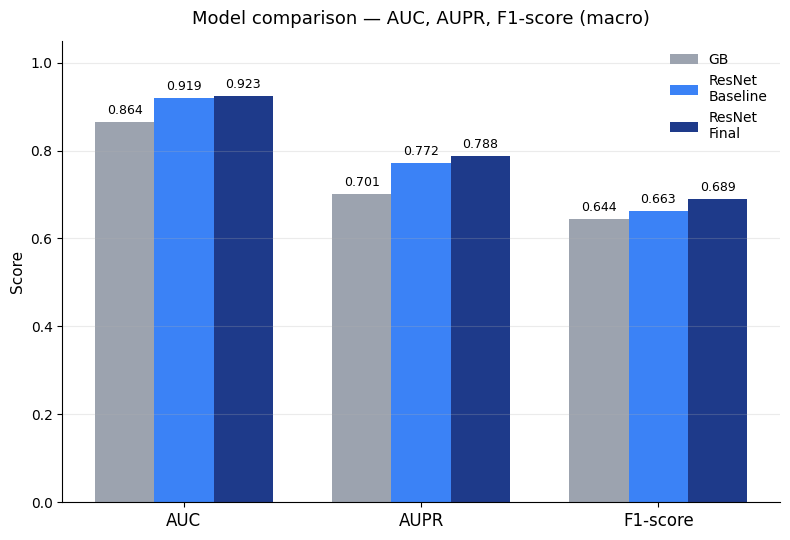

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ── data ────────────────────────────────────────────────────────────────────
models  = ["GB", "ResNet\nBaseline", "ResNet\nFinal"]
metrics = ["AUC", "AUPR", "F1-score"]

values = {
    "AUC":      [0.864, 0.919, 0.923],
    "AUPR":     [0.701, 0.772, 0.788],
    "F1-score": [0.644, 0.663, 0.689],
}

colors = ["#9CA3AF", "#3B82F6", "#1E3A8A"]  # GB grey, baseline mid-blue, final dark navy

# ── plot ──────────────────────────────────────────────────────────────────────
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5.5))

for i, model in enumerate(models):
    offsets = (i - 1) * width
    vals = [values[m][i] for m in metrics]
    bars = ax.bar(x + offsets, vals, width, label=model, color=colors[i])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model comparison — AUC, AUPR, F1-score (macro)", fontsize=13, pad=12)
ax.legend(frameon=False, fontsize=10,)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}model_comparison_auc_aupr_f1.svg", format="svg", bbox_inches="tight")
plt.show()